## **SETUP GOOGLE COLAB & GOOGLE DRIVE and IMPORT**

In [1]:
# SETUP & IMPORTS

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)


print("EARLY DOG ILLNESS DETECTION SYSTEM - KAGGLE VERSION")

print(f"\n TensorFlow Version: {tf.__version__}")
print(f" GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f" GPU Devices: {tf.config.list_physical_devices('GPU')}")

# Kaggle directories
KAGGLE_INPUT = '/kaggle/input'
WORKING_DIR = '/kaggle/working'

# Create output directories
os.makedirs(f'{WORKING_DIR}/models', exist_ok=True)
os.makedirs(f'{WORKING_DIR}/visualizations', exist_ok=True)

print(f"\n Kaggle Input Directory: {KAGGLE_INPUT}")
print(f" Working Directory: {WORKING_DIR}")

# List all available input datasets
print(f"\n Available Input Datasets:")
for item in os.listdir(KAGGLE_INPUT):
    print(f"  • {item}")

print("SETUP COMPLETE!")

2026-01-18 10:35:03.100078: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768732503.262620      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768732503.310555      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

EARLY DOG ILLNESS DETECTION SYSTEM - KAGGLE VERSION

 TensorFlow Version: 2.18.0
 GPU Available: True
 GPU Devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

 Kaggle Input Directory: /kaggle/input
 Working Directory: /kaggle/working

 Available Input Datasets:
  • dog-illness-detection-processed-data
SETUP COMPLETE!


## **LOAD NORMAL DATA**

In [2]:
# LOAD PROCESSED DATA

print("LOADING PROCESSED DATA")

# Find your dataset folder (auto-detect)
dataset_path = None
for item in os.listdir(KAGGLE_INPUT):
    item_lower = item.lower()
    # Look for keywords in your dataset name
    if any(keyword in item_lower for keyword in ['dog', 'illness', 'processed', 'detection']):
        dataset_path = os.path.join(KAGGLE_INPUT, item)
        break

# If not found by keyword, use first available dataset
if not dataset_path:
    available_datasets = os.listdir(KAGGLE_INPUT)
    if available_datasets:
        dataset_path = os.path.join(KAGGLE_INPUT, available_datasets[0])
    else:
        raise FileNotFoundError("No datasets found! Please add your dataset to the notebook.")

print(f"\n Using Dataset: {dataset_path}")

# List all files in the dataset
print(f"\n Files in Dataset:")
for file in os.listdir(dataset_path):
    file_path = os.path.join(dataset_path, file)
    if os.path.isfile(file_path):
        size_mb = os.path.getsize(file_path) / 1e6
        print(f"  • {file} ({size_mb:.1f} MB)")

# Load the .npy files
print(f"\n Loading data files...")
normal_data = np.load(f'{dataset_path}/normal_data.npy')
abnormal_data = np.load(f'{dataset_path}/abnormal_data.npy')

print(f"\n Data Loaded Successfully!")
print(f"  • Normal sequences: {normal_data.shape}")
print(f"  • Abnormal sequences: {abnormal_data.shape}")
print(f"  • Total memory: {(normal_data.nbytes + abnormal_data.nbytes) / 1e9:.2f} GB")
print(f"  • Data type: {normal_data.dtype}")
print(f"  • Value range: [{normal_data.min():.3f}, {normal_data.max():.3f}]")

print("✓ DATA LOADING COMPLETE!")

LOADING PROCESSED DATA

 Using Dataset: /kaggle/input/dog-illness-detection-processed-data

 Files in Dataset:
  • normal_data.npy (1535.4 MB)
  • abnormal_data.npy (1445.1 MB)

 Loading data files...

 Data Loaded Successfully!
  • Normal sequences: (85, 30, 224, 224, 3)
  • Abnormal sequences: (80, 30, 224, 224, 3)
  • Total memory: 2.98 GB
  • Data type: float32
  • Value range: [0.000, 1.000]
✓ DATA LOADING COMPLETE!


## **PREPARE TRAINING DATASET**

In [3]:
# PREPARE TRAINING DATASET

print("PREPARING TRAINING DATASET")

# Balance datasets (use minimum count to ensure equal samples)
min_samples = min(len(normal_data), len(abnormal_data))
normal_data = normal_data[:min_samples]
abnormal_data = abnormal_data[:min_samples]

print(f"\n Balanced to {min_samples} samples per class")
print(f"  • Normal: {len(normal_data)} sequences")
print(f"  • Abnormal: {len(abnormal_data)} sequences")

# Combine normal (label=0) and abnormal (label=1)
X = np.concatenate([normal_data, abnormal_data])
y = np.array([0] * len(normal_data) + [1] * len(abnormal_data))

print(f"\n Combined Dataset:")
print(f"  • Total samples: {len(X)}")
print(f"  • Shape: {X.shape}")
print(f"  • Labels shape: {y.shape}")
print(f"  • Class distribution: {np.bincount(y)}")

# Free memory
del normal_data, abnormal_data
import gc
gc.collect()

print(f"\n Memory cleared")

# Shuffle the dataset
X, y = shuffle(X, y, random_state=42)
print(f" Data shuffled")

# Split into train/validation/test (70% / 15% / 15%)
print(f"\n Splitting dataset...")

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.3, 
    stratify=y, 
    random_state=42
)

# Second split: 15% validation, 15% test (50/50 split of the 30%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.5, 
    stratify=y_temp, 
    random_state=42
)

# Display dataset statistics
print("DATASET STATISTICS")

print(f"\n Training Set: {len(X_train)} samples")
print(f"  • Normal: {np.sum(y_train==0)} ({np.mean(y_train==0)*100:.1f}%)")
print(f"  • Abnormal: {np.sum(y_train==1)} ({np.mean(y_train==1)*100:.1f}%)")

print(f"\n Validation Set: {len(X_val)} samples")
print(f"  • Normal: {np.sum(y_val==0)} ({np.mean(y_val==0)*100:.1f}%)")
print(f"  • Abnormal: {np.sum(y_val==1)} ({np.mean(y_val==1)*100:.1f}%)")

print(f"\n Test Set: {len(X_test)} samples")
print(f"  • Normal: {np.sum(y_test==0)} ({np.mean(y_test==0)*100:.1f}%)")
print(f"  • Abnormal: {np.sum(y_test==1)} ({np.mean(y_test==1)*100:.1f}%)")

# Save splits for later use
np.save(f'{WORKING_DIR}/X_train.npy', X_train)
np.save(f'{WORKING_DIR}/y_train.npy', y_train)
np.save(f'{WORKING_DIR}/X_val.npy', X_val)
np.save(f'{WORKING_DIR}/y_val.npy', y_val)
np.save(f'{WORKING_DIR}/X_test.npy', X_test)
np.save(f'{WORKING_DIR}/y_test.npy', y_test)

print(f"\n Datasets saved to {WORKING_DIR}")

# Clear memory
del X, X_temp, y_temp
gc.collect()

print("DATA PREPARATION COMPLETE!")

print(f"\n Summary:")
print(f"  • Total original samples: {min_samples * 2}")
print(f"  • Training samples: {len(X_train)} (~70%)")
print(f"  • Validation samples: {len(X_val)} (~15%)")
print(f"  • Test samples: {len(X_test)} (~15%)")
print(f"\n Ready for model training!")

PREPARING TRAINING DATASET

 Balanced to 80 samples per class
  • Normal: 80 sequences
  • Abnormal: 80 sequences

 Combined Dataset:
  • Total samples: 160
  • Shape: (160, 30, 224, 224, 3)
  • Labels shape: (160,)
  • Class distribution: [80 80]

 Memory cleared
 Data shuffled

 Splitting dataset...
DATASET STATISTICS

 Training Set: 112 samples
  • Normal: 56 (50.0%)
  • Abnormal: 56 (50.0%)

 Validation Set: 24 samples
  • Normal: 12 (50.0%)
  • Abnormal: 12 (50.0%)

 Test Set: 24 samples
  • Normal: 12 (50.0%)
  • Abnormal: 12 (50.0%)

 Datasets saved to /kaggle/working
DATA PREPARATION COMPLETE!

 Summary:
  • Total original samples: 160
  • Training samples: 112 (~70%)
  • Validation samples: 24 (~15%)
  • Test samples: 24 (~15%)

 Ready for model training!


## **BUILD & TRAIN OPTIMIZED MODEL** 

In [4]:
# BUILD & TRAIN OPTIMIZED MODEL (IMPROVED VERSION)

print("BUILDING & TRAINING IMPROVED CNN+LSTM MODEL")

# Check GPU
gpus = tf.config.list_physical_devices('GPU')
print(f"\n GPU: {gpus}")

# Build model
video_input = layers.Input(shape=(30, 224, 224, 3), name='video_input')

base_cnn = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_cnn.layers[:100]:
    layer.trainable = False

cnn_model = tf.keras.Sequential([
    base_cnn,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3)
], name='cnn_extractor')

cnn_features = layers.TimeDistributed(cnn_model)(video_input)

# IMPROVED: Larger LSTM units
lstm_out = layers.LSTM(
    256,
    return_sequences=True,
    kernel_regularizer=regularizers.l2(0.01),
    recurrent_dropout=0.2
)(cnn_features)
lstm_out = layers.Dropout(0.5)(lstm_out)

lstm_out = layers.LSTM(
    128,
    kernel_regularizer=regularizers.l2(0.01),
    recurrent_dropout=0.2
)(lstm_out)
lstm_out = layers.Dropout(0.5)(lstm_out)

# IMPROVED: Deeper classification head
dense_out = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01))(lstm_out)
dense_out = layers.Dropout(0.3)(dense_out)
dense_out = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01))(dense_out)
dense_out = layers.Dropout(0.4)(dense_out)
output = layers.Dense(1, activation='sigmoid')(dense_out)

model = Model(inputs=video_input, outputs=output, name='ImprovedDogIllnessDetector')

# Compile
initial_learning_rate = 0.001
model.compile(
    optimizer=tf.keras.optimizers.Adam(initial_learning_rate),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.AUC(name='auc')]
)

print("\n Model built!")
model.summary()

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=1),
    ModelCheckpoint(f'{WORKING_DIR}/models/best_model_improved.h5', 
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

# IMPROVED: Train longer
print("TRAINING (80 epochs)...")

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=8,
    callbacks=callbacks,
    verbose=1
)

print("\n TRAINING COMPLETE!")
model.save(f'{WORKING_DIR}/models/final_model_improved.h5')

BUILDING & TRAINING IMPROVED CNN+LSTM MODEL

 GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


I0000 00:00:1768732537.518845      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1768732537.519464      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

 Model built!


Model: "ImprovedDogIllnessDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ video_input (InputLayer)        │ (None, 30, 224, 224,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 1280)       │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30, 256)        │     1,573,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 943ms/step - accuracy: 0.5700 - auc: 0.5252 - loss: 9.6833 - precision: 0.5658 - recall: 0.5323 - val_accuracy: 0.6667 - val_auc: 0.7292 - val_loss: 6.6637 - val_precision: 1.0000 - val_recall: 0.3333 - learning_rate: 0.0010
Epoch 3/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 803ms/step - accuracy: 0.6514 - auc: 0.7142 - loss: 6.0345 - precision: 0.6248 - recall: 0.7303
Epoch 3: val_accuracy improved from 0.66667 to 0.79167, saving model to /kaggle/working/models/best_model_improved.h5


14/14 ━━━━━━━━━━━━━━━━━━━━ 14s 964ms/step - accuracy: 0.6538 - auc: 0.7157 - loss: 5.9962 - precision: 0.6272 - recall: 0.7328 - val_accuracy: 0.7917 - val_auc: 0.7778 - val_loss: 4.2887 - val_precision: 1.0000 - val_recall: 0.5833 - learning_rate: 0.0010
Epoch 4/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 817ms/step - accuracy: 0.7190 - auc: 0.8044 - loss: 3.9895 - precision: 0.7420 - recall: 0.6638
Epoch 4: val_accuracy did not improve from 0.79167
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 946ms/step - accuracy: 0.7211 - auc: 0.8069 - loss: 3.9690 - precision: 0.7462 - recall: 0.6636 - val_accuracy: 0.5833 - val_auc: 0.7778 - val_loss: 3.5589 - val_precision: 0.5500 - val_recall: 0.9167 - learning_rate: 0.0010
Epoch 5/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 812ms/step - accuracy: 0.7057 - auc: 0.8039 - loss: 3.0116 - precision: 0.6996 - recall: 0.7052
Epoch 5: val_accuracy did not improve from 0.79167
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 940ms/step - accuracy: 0.7087 - auc: 0.8064 - loss: 2.9983 - precision: 0.7050 - 

14/14 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9230 - auc: 0.9386 - loss: 0.8513 - precision: 0.9815 - recall: 0.8636 - val_accuracy: 0.8333 - val_auc: 0.8472 - val_loss: 0.9518 - val_precision: 0.8333 - val_recall: 0.8333 - learning_rate: 0.0010
Epoch 18/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 797ms/step - accuracy: 0.8983 - auc: 0.9306 - loss: 0.8792 - precision: 0.9985 - recall: 0.7936
Epoch 18: val_accuracy did not improve from 0.83333
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 919ms/step - accuracy: 0.8985 - auc: 0.9305 - loss: 0.8785 - precision: 0.9972 - recall: 0.7955 - val_accuracy: 0.7083 - val_auc: 0.8021 - val_loss: 1.4492 - val_precision: 0.6667 - val_recall: 0.8333 - learning_rate: 0.0010
Epoch 19/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 796ms/step - accuracy: 0.9610 - auc: 0.9913 - loss: 0.6835 - precision: 1.0000 - recall: 0.9220
Epoch 19: val_accuracy did not improve from 0.83333
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 924ms/step - accuracy: 0.9607 - auc: 0.9902 - loss: 0.6855 - precision: 1.0000 -

14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 955ms/step - accuracy: 0.9375 - auc: 0.9709 - loss: 0.6281 - precision: 0.9310 - recall: 0.9430 - val_accuracy: 0.8750 - val_auc: 0.8611 - val_loss: 0.8359 - val_precision: 0.9091 - val_recall: 0.8333 - learning_rate: 0.0010
Epoch 24/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 796ms/step - accuracy: 0.9360 - auc: 0.9901 - loss: 0.5987 - precision: 0.9520 - recall: 0.9201
Epoch 24: val_accuracy did not improve from 0.87500
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 923ms/step - accuracy: 0.9367 - auc: 0.9891 - loss: 0.5998 - precision: 0.9516 - recall: 0.9219 - val_accuracy: 0.8750 - val_auc: 0.9306 - val_loss: 0.8216 - val_precision: 0.9091 - val_recall: 0.8333 - learning_rate: 0.0010
Epoch 25/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 797ms/step - accuracy: 0.9688 - auc: 0.9988 - loss: 0.4796 - precision: 1.0000 - recall: 0.9382
Epoch 25: val_accuracy did not improve from 0.87500
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 919ms/step - accuracy: 0.9691 - auc: 0.9983 - loss: 0.4785 - precision: 1.000


 TRAINING COMPLETE!


## **EXTRACT MODEL WEIGHTS FOR DEPLOYMENT**

In [5]:
# EXTRACT MODEL WEIGHTS FOR DEPLOYMENT

import tensorflow as tf
from tensorflow import keras
import numpy as np
import json
import os

print("EXTRACTING MODEL WEIGHTS FOR DEPLOYMENT")

# Load the best model
model_path = '/kaggle/working/models/best_model_improved.h5'
print(f"Loading model from: {model_path}")

model = keras.models.load_model(model_path, compile=False)
print(f"Model loaded successfully!")
print(f"   \nTotal params: {model.count_params():,}")

# Extract all weights
weights_dict = {}
weight_count = 0

for layer in model.layers:
    layer_weights = layer.get_weights()
    if len(layer_weights) > 0:
        # Convert numpy arrays to lists for JSON serialization
        weights_dict[layer.name] = [w.tolist() for w in layer_weights]
        weight_count += len(layer_weights)
        print(f"Extracted: {layer.name:30s} - {len(layer_weights)} arrays")

print(f"\nTotal weight arrays extracted: {weight_count}")

# Save weights as JSON
weights_file = '/kaggle/working/model_weights.json'
print(f"\nSaving weights to JSON...")

with open(weights_file, 'w') as f:
    json.dump(weights_dict, f)

file_size = os.path.getsize(weights_file) / (1024*1024)
print(f"Weights saved!")
print(f"   File: {weights_file}")
print(f"   Size: {file_size:.1f} MB")

# Save model architecture config
print(f"\nSaving model config...")

config_dict = {
    'class_name': model.__class__.__name__,
    'input_shape': str(model.input_shape),
    'output_shape': str(model.output_shape),
    'total_params': int(model.count_params()),
    'layer_count': len(model.layers),
    'layer_names': [layer.name for layer in model.layers]
}

config_file = '/kaggle/working/model_config.json'
with open(config_file, 'w') as f:
    json.dump(config_dict, f, indent=2)

print(f"Config saved!")
print(f"   File: {config_file}")

print("\nEXTRACTION COMPLETE!")

print(f"   1. {weights_file}")
print(f"   2. {config_file}")
print("\nFiles are in: /kaggle/working/")

EXTRACTING MODEL WEIGHTS FOR DEPLOYMENT
Loading model from: /kaggle/working/models/best_model_improved.h5
Model loaded successfully!
   
Total params: 4,039,361
Extracted: time_distributed               - 260 arrays
Extracted: lstm                           - 3 arrays
Extracted: lstm_1                         - 3 arrays
Extracted: dense                          - 2 arrays
Extracted: dense_1                        - 2 arrays
Extracted: dense_2                        - 2 arrays

Total weight arrays extracted: 272

Saving weights to JSON...
Weights saved!
   File: /kaggle/working/model_weights.json
   Size: 86.7 MB

Saving model config...
Config saved!
   File: /kaggle/working/model_config.json

EXTRACTION COMPLETE!
   1. /kaggle/working/model_weights.json
   2. /kaggle/working/model_config.json

Files are in: /kaggle/working/


## **RECOMPILE MODEL AFTER LOADING**

In [6]:
# RECOMPILE MODEL AFTER LOADING

print("RECOMPILING MODEL")

# Recompile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)

print("Model recompiled successfully!")

RECOMPILING MODEL
Model recompiled successfully!


## **MODEL EVALUATION & VISUALIZATION**

MODEL EVALUATION & VISUALIZATION

 Evaluating model on test set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 59s 59s/step - accuracy: 0.8750 - auc: 0.9514 - loss: 0.7647 - precision: 1.0000 - recall: 0.7500
TEST SET PERFORMANCE
Loss:       0.7647
Accuracy:   87.50%
Precision:  100.00%
Recall:     75.00%
F1-Score:   85.71%
AUC:        0.9514

 EXCELLENT! Accuracy ≥ 80% - Production Ready!

 Generating predictions on test set...
CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal     0.8000    1.0000    0.8889        12
    Abnormal     1.0000    0.7500    0.8571        12

    accuracy                         0.8750        24
   macro avg     0.9000    0.8750    0.8730        24
weighted avg     0.9000    0.8750    0.8730        24

CONFUSION MATRIX
                Predicted Normal  Predicted Abnormal
Actual Normal              12                  0
Actual Abnormal             3                  9

Specificity (TNR): 100.00%
Sensitivity (TPR): 75.00%

 Creating visu

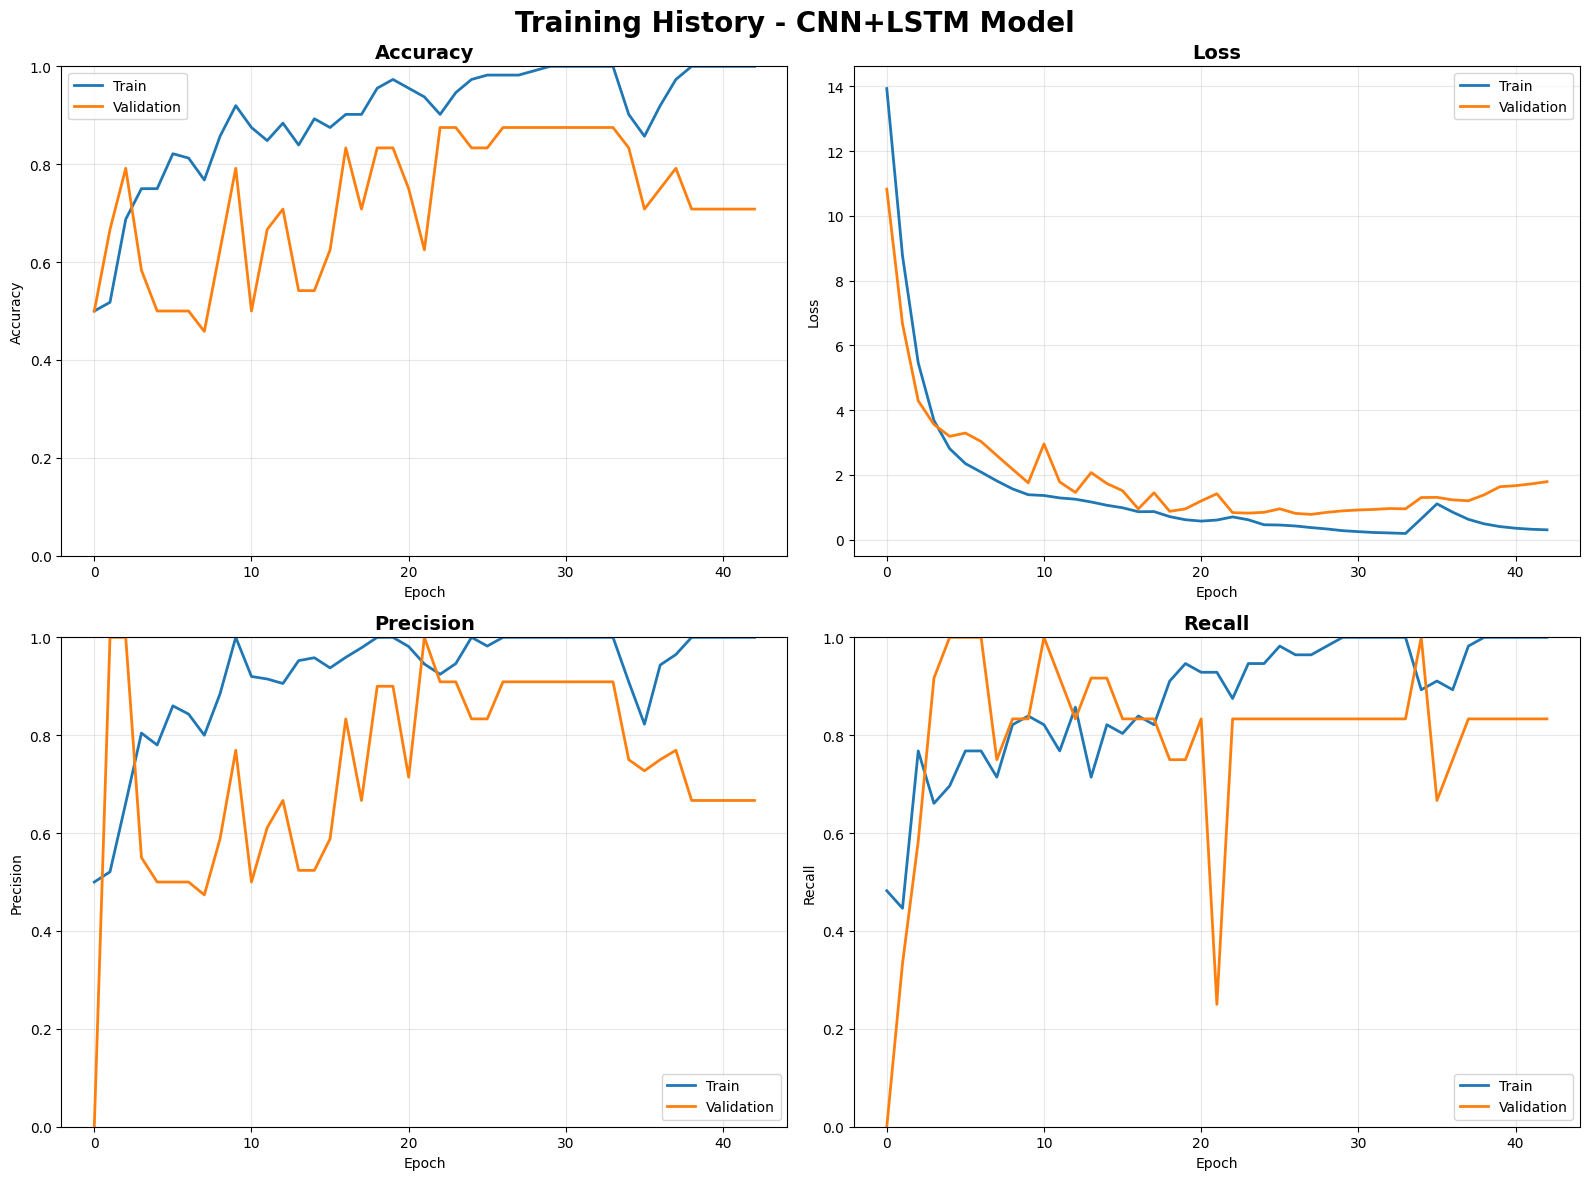

  • Confusion matrix heatmap...


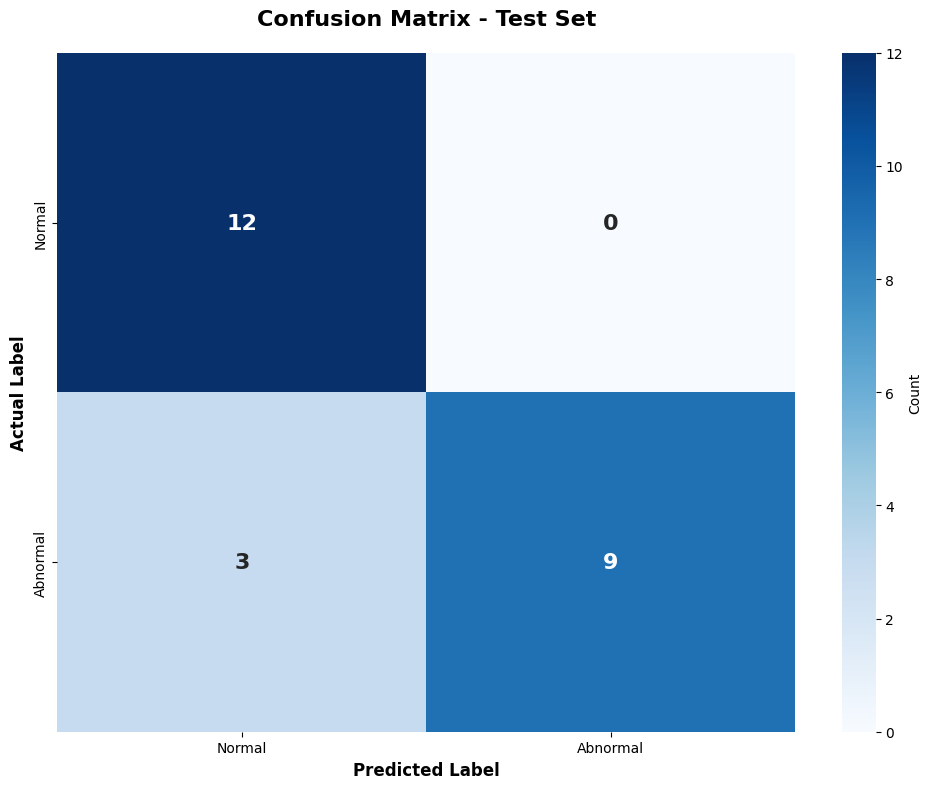

  • ROC curve...


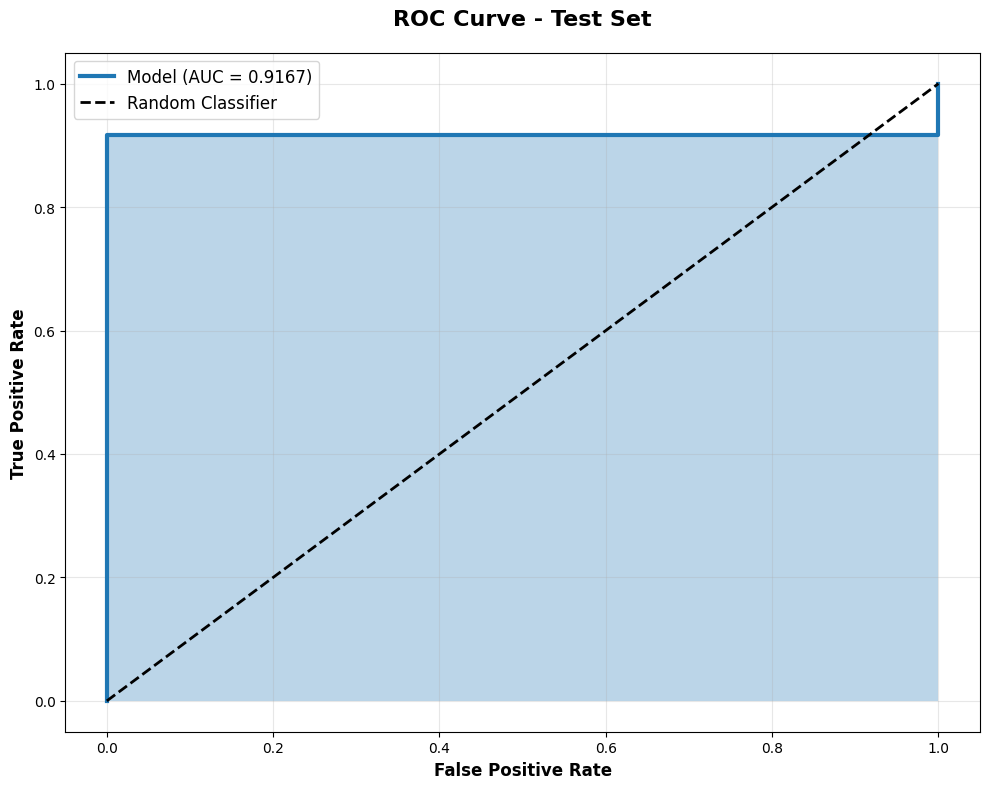


 Saving results...
Saved: test_results.json
EVALUATION COMPLETE!
   1. model_weights.json (86.7 MB)
   2. model_config.json
   3. test_results.json
   4. visualizations/ folder


In [7]:
# MODEL EVALUATION & VISUALIZATION

print("MODEL EVALUATION & VISUALIZATION")

# STEP 1: MODEL EVALUATION
print("\n Evaluating model on test set...")
test_results = model.evaluate(X_test, y_test, verbose=1)

# Extract metrics
test_loss = test_results[0]
test_acc  = test_results[1]
test_prec = test_results[2]
test_rec  = test_results[3]
test_auc  = test_results[4]

# Calculate F1-score
f1 = 2 * (test_prec * test_rec) / (test_prec + test_rec + 1e-7)

# Display results
print("TEST SET PERFORMANCE")
print(f"Loss:       {test_loss:.4f}")
print(f"Accuracy:   {test_acc*100:.2f}%")
print(f"Precision:  {test_prec*100:.2f}%")
print(f"Recall:     {test_rec*100:.2f}%")
print(f"F1-Score:   {f1*100:.2f}%")
print(f"AUC:        {test_auc:.4f}")

# Performance assessment
if test_acc >= 0.80:
    print("\n EXCELLENT! Accuracy ≥ 80% - Production Ready!")
elif test_acc >= 0.70:
    print("\n GOOD! Accuracy ≥ 70% - Proof of Concept Successful!")
else:
    print("\n Accuracy < 70% - Needs improvement")

# STEP 2: PREDICTIONS
print("\n Generating predictions on test set...")
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# STEP 3: CLASSIFICATION REPORT
print("CLASSIFICATION REPORT")
print(classification_report(
    y_test, y_pred,
    target_names=['Normal', 'Abnormal'],
    digits=4
))

# STEP 4: CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("CONFUSION MATRIX")
print(f"{'':>15} Predicted Normal  Predicted Abnormal")
print(f"Actual Normal        {tn:>8}           {fp:>8}")
print(f"Actual Abnormal      {fn:>8}           {tp:>8}")

# Additional metrics
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0

print(f"\nSpecificity (TNR): {specificity*100:.2f}%")
print(f"Sensitivity (TPR): {sensitivity*100:.2f}%")

# STEP 5: VISUALIZATIONS
print("\n Creating visualizations...")

# 5.1 Training History
print("  • Training history plots...")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Training History - CNN+LSTM Model', fontsize=20, fontweight='bold')

axes[0,0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0,0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0,0].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)
axes[0,0].set_ylim([0, 1])

axes[0,1].plot(history.history['loss'], label='Train', linewidth=2)
axes[0,1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[0,1].set_title('Loss', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Loss')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(history.history['precision'], label='Train', linewidth=2)
axes[1,0].plot(history.history['val_precision'], label='Validation', linewidth=2)
axes[1,0].set_title('Precision', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Precision')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)
axes[1,0].set_ylim([0, 1])

axes[1,1].plot(history.history['recall'], label='Train', linewidth=2)
axes[1,1].plot(history.history['val_recall'], label='Validation', linewidth=2)
axes[1,1].set_title('Recall', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('Recall')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)
axes[1,1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/visualizations/training_history.png', dpi=300, bbox_inches='tight')
plt.show()

# 5.2 Confusion Matrix
print("  • Confusion matrix heatmap...")
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Abnormal'],
    yticklabels=['Normal', 'Abnormal'],
    cbar_kws={'label': 'Count'},
    annot_kws={'size': 16, 'weight': 'bold'}
)
plt.title('Confusion Matrix - Test Set', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Actual Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/visualizations/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# 5.3 ROC Curve
print("  • ROC curve...")
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, linewidth=3, label=f'Model (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.3)
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curve - Test Set', fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/visualizations/roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# STEP 6: SAVE RESULTS
print("\n Saving results...")

results = {
    'test_metrics': {
        'accuracy': float(test_acc),
        'precision': float(test_prec),
        'recall': float(test_rec),
        'f1_score': float(f1),
        'auc': float(test_auc),
        'loss': float(test_loss),
        'specificity': float(specificity),
        'sensitivity': float(sensitivity)
    },
    'confusion_matrix': {
        'true_negatives': int(tn),
        'false_positives': int(fp),
        'false_negatives': int(fn),
        'true_positives': int(tp)
    }
}

with open(f'{WORKING_DIR}/test_results.json', 'w') as f:
    json.dump(results, f, indent=4)

print("Saved: test_results.json")

print("EVALUATION COMPLETE!")

print("   1. model_weights.json (86.7 MB)")
print("   2. model_config.json")
print("   3. test_results.json")
print("   4. visualizations/ folder")

## **THRESHOLD OPTIMIZATION**

In [8]:
print("TESTING DIFFERENT DECISION THRESHOLDS")

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for thresh in thresholds:
    y_pred_thresh = (y_pred_prob > thresh).astype(int).flatten()
    cm = confusion_matrix(y_test, y_pred_thresh)
    tn, fp, fn, tp = cm.ravel()
    
    acc = (tp + tn) / (tp + tn + fp + fn)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (prec * rec) / (prec + rec + 1e-7)
    
    print(f"\nThreshold: {thresh}")
    print(f"  Accuracy:  {acc*100:.2f}%")
    print(f"  Precision: {prec*100:.2f}%")
    print(f"  Recall:    {rec*100:.2f}%")
    print(f"  F1-Score:  {f1*100:.2f}%")
    print(f"  Confusion: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

TESTING DIFFERENT DECISION THRESHOLDS

Threshold: 0.3
  Accuracy:  91.67%
  Precision: 100.00%
  Recall:    83.33%
  F1-Score:  90.91%
  Confusion: TN=12, FP=0, FN=2, TP=10

Threshold: 0.4
  Accuracy:  87.50%
  Precision: 100.00%
  Recall:    75.00%
  F1-Score:  85.71%
  Confusion: TN=12, FP=0, FN=3, TP=9

Threshold: 0.5
  Accuracy:  87.50%
  Precision: 100.00%
  Recall:    75.00%
  F1-Score:  85.71%
  Confusion: TN=12, FP=0, FN=3, TP=9

Threshold: 0.6
  Accuracy:  79.17%
  Precision: 100.00%
  Recall:    58.33%
  F1-Score:  73.68%
  Confusion: TN=12, FP=0, FN=5, TP=7

Threshold: 0.7
  Accuracy:  75.00%
  Precision: 100.00%
  Recall:    50.00%
  F1-Score:  66.67%
  Confusion: TN=12, FP=0, FN=6, TP=6
